## **BAB 12. ETIKA SAINS DATA**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score

# Misalkan df_eval berisi label asli, prediksi, dan kelompok
# Kolom: y_true, y_pred, kelompok

# FIX: Define df_eval with some dummy data for demonstration
# In a real scenario, you would load your actual evaluation data here.
df_eval = pd.DataFrame({
    'y_true': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    'y_pred': [0, 1, 1, 1, 0, 0, 0, 1, 1, 1],
    'kelompok': ['A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'C', 'C']
})

hasil_kelompok = []

for kelompok, data_k in df_eval.groupby("kelompok"):
    akurasi = accuracy_score(data_k["y_true"], data_k["y_pred"])

    hasil_kelompok.append({
        "kelompok": kelompok,
        "jumlah_data": len(data_k),
        "akurasi": akurasi
    })

hasil_fairness = pd.DataFrame(hasil_kelompok)

print(hasil_fairness)

  kelompok  jumlah_data  akurasi
0        A            4     0.75
1        B            4     0.75
2        C            2     0.50


Jika targetnya biner dan kelas positif penting, recall per kelompok juga dapat diperiksa.

In [ ]:
hasil_kelompok = []

for kelompok, data_k in df_eval.groupby("kelompok"):
    recall = recall_score(
        data_k["y_true"],
        data_k["y_pred"],
        pos_label=1 # Changed 'ya' to 1
    )

    hasil_kelompok.append({
        "kelompok": kelompok,
        "jumlah_data": len(data_k),
        "recall_kelas_positif": recall
    })

hasil_recall = pd.DataFrame(hasil_kelompok)

print(hasil_recall)

  kelompok  jumlah_data  recall_kelas_positif
0        A            4                   1.0
1        B            4                   0.5
2        C            2                   1.0


Berikut adalah penjelasan mengenai blok kode ini:

Blok kode ini terlebih dahulu menginstal pustaka `faker` (yang terlihat dari output instalasi yang berhasil), yang umumnya digunakan untuk menghasilkan data palsu. Setelah instalasi, ia mendefinisikan tiga fungsi Python yang bertujuan untuk anonimisasi dan privasi data:

1.  **`pseudonimisasi_hashing(df, kolom_id, kolom_sensitif, salt)`**: Fungsi ini melakukan pseudonimisasi menggunakan hashing SHA-256. Ia mengganti pengenal sensitif (`kolom_id`) dengan nilai hash yang tidak dapat dipulihkan, memastikan ID yang sama selalu menghasilkan pseudonim yang sama (konsisten). Ini juga sepenuhnya menghapus kolom sensitif lainnya (`kolom_sensitif`) dari DataFrame. Parameter `salt` sangat penting untuk keamanan, karena membuat hashing lebih kuat.

2.  **`generalisasi_data(df, kolom_usia, kolom_lokasi, bins_usia)`**: Fungsi ini menggeneralisasi data untuk mengurangi presisi atribut tertentu, sehingga menurunkan risiko re-identifikasi. Secara khusus, ini mengubah:
    *   `kolom_usia` (usia) menjadi rentang usia (misalnya, 18-24, 25-34), menghapus kolom usia asli.
    *   `kolom_lokasi` (lokasi) menjadi tingkat yang lebih umum, seperti hanya provinsi atau wilayah utama, menghapus lokasi rinci asli.

3.  **`cek_k_anonymity(df, quasi_identifiers, k)`**: Fungsi ini memeriksa apakah kumpulan data memenuhi model privasi `k`-anonimitas. `k`-anonimitas memastikan bahwa untuk setiap kombinasi `quasi_identifiers` (atribut yang berpotensi dapat mengidentifikasi individu, seperti rentang usia dan lokasi yang digeneralisasi), setidaknya ada `k` individu yang berbagi kombinasi tersebut. Fungsi ini melaporkan apakah kumpulan data memenuhi kondisi ini dan, jika tidak, mengidentifikasi kombinasi yang melanggarnya dan persentase baris yang berisiko.

In [ ]:
!pip install faker

import pandas as pd
import hashlib
import numpy as np
from faker import Faker

# ── Pseudonimisasi dengan hashing ──
def pseudonimisasi_hashing(df, kolom_id, kolom_sensitif,
                             salt='rahasia_bukan_ini'):
    """
    Pseudonimisasi kolom ID menggunakan hash SHA-256.
    Konsisten: ID yang sama selalu menghasilkan pseudonim yang sama.
    Tidak dapat dipulihkan tanpa salt.
    """
    df = df.copy()

    # Pseudonimisasi ID
    def hash_id(x):
        return hashlib.sha256(f'{salt}{x}'.encode()).hexdigest()[:16]

    df[kolom_id] = df[kolom_id].astype(str).apply(hash_id)

    # Hapus kolom sensitif langsung
    for col in kolom_sensitif:
        if col in df.columns:
            df = df.drop(columns=[col])

    return df

# ── Generalisasi: mengurangi presisi untuk mencegah re-identifikasi ──
def generalisasi_data(df, kolom_usia, kolom_lokasi,
                       bins_usia=[18,25,35,45,55,65,100]):
    """Generalisasi nilai untuk mengurangi risiko re-identifikasi."""
    df = df.copy()

    # Usia → rentang usia
    labels = [f'{a}-{b-1}' for a,b in zip(bins_usia[:-1], bins_usia[1:])]
    df[kolom_usia+'_rentang'] = pd.cut(
        df[kolom_usia], bins=bins_usia, labels=labels, right=False
    ).astype(str)
    df = df.drop(columns=[kolom_usia])

    # Lokasi → generalisasi ke level provinsi
    if kolom_lokasi in df.columns:
        df[kolom_lokasi+'_umum'] = df[kolom_lokasi].apply(
            lambda x: x.split(',')[0] if isinstance(x,str) else x
        )
        df = df.drop(columns=[kolom_lokasi])

    return df

# ── k-Anonymity sederhana: pastikan setiap kombinasi quasi-identifier
# muncul minimal k kali ──
def cek_k_anonymity(df, quasi_identifiers, k=5):
    """Memeriksa apakah dataset memenuhi k-anonymity."""
    kelompok = df.groupby(quasi_identifiers).size().reset_index(name='n')
    pelanggaran = kelompok[kelompok['n'] < k]
    if len(pelanggaran) == 0:
        print(f'✓ Dataset memenuhi {k}-anonymity')
    else:
        print(f'✗ {len(pelanggaran)} kombinasi melanggar {k}-anonymity')
        print(pelanggaran.head())
    pct_rentan = len(
        df.merge(pelanggaran[quasi_identifiers], on=quasi_identifiers)
    ) / len(df) * 100
    print(f'  {pct_rentan:.1f}% baris berisiko re-identifikasi')
    return pelanggaran

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.3 MB/s eta 0:00:00


/tmp/ipykernel_1249/1721598357.py:43: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

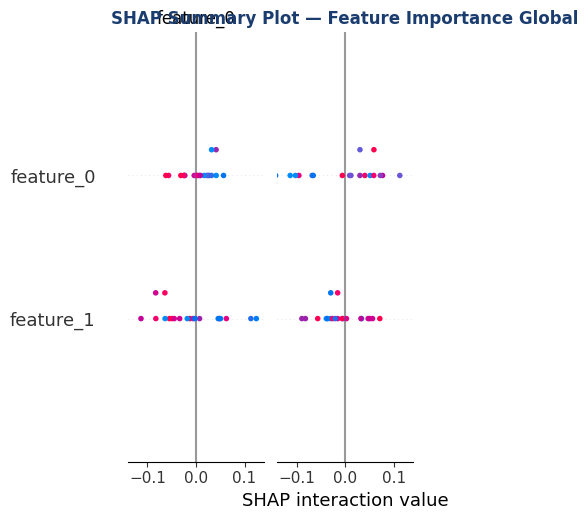

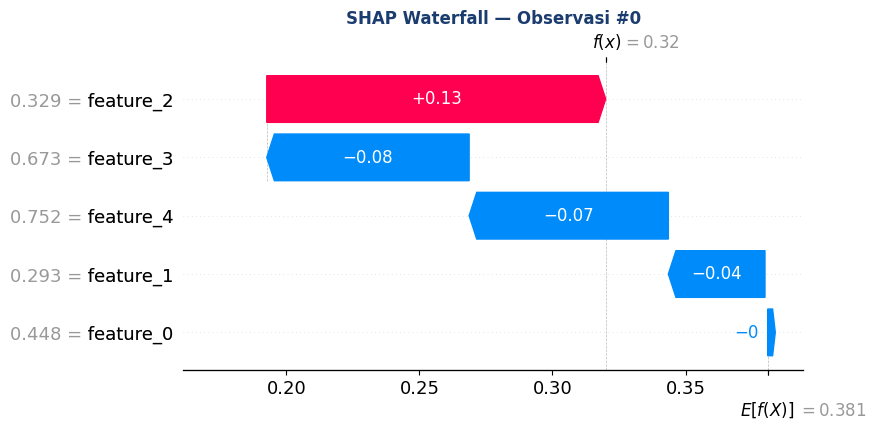

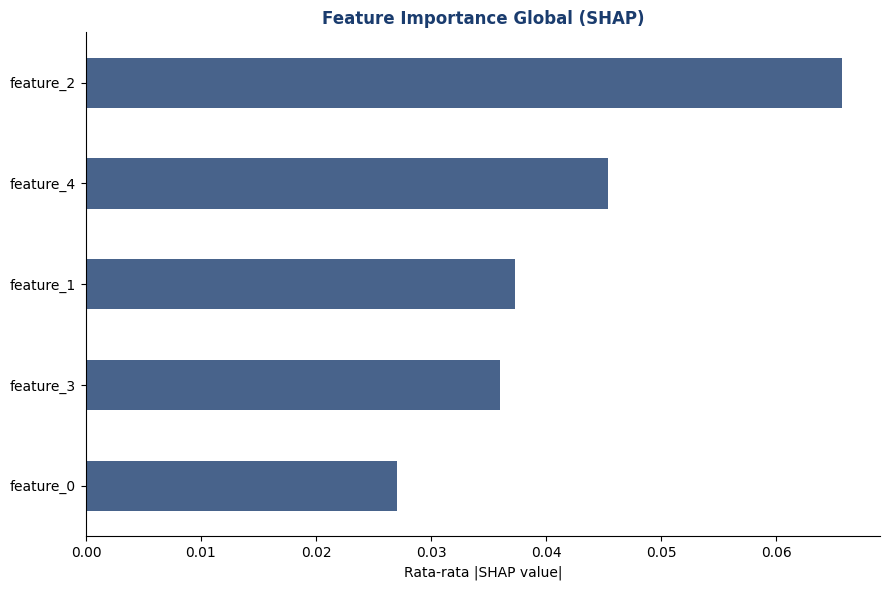

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# --- FIX: Define model_rf, X_test, and kolom_fitur ---
# In a real application, you would load or train your actual model and data.
# For demonstration, let's create a dummy dataset and a trained model.

# Create a synthetic dataset
np.random.seed(42)
data_size = 100
X = pd.DataFrame(np.random.rand(data_size, 5), columns=[f'feature_{i}' for i in range(5)])
y = pd.Series(np.random.randint(0, 2, data_size))

# Define feature names
kolom_fitur = X.columns.tolist()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestClassifier model
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
# --- End of FIX ---


# ── Menghitung SHAP values ──
# model harus sudah dilatih
explainer = shap.TreeExplainer(model_rf)   # Cepat untuk tree-based
shap_values = explainer.shap_values(X_test)

# Untuk multi-kelas, shap_values bisa berupa list [kelas_0, kelas_1, ...] atau array 3D (samples, features, outputs)
# sv digunakan untuk summary plot, yang bisa menangani format 3D atau list. Jadi sv tetap seperti aslinya.
# Untuk waterfall plot dan fungsi jelaskan_prediksi, kita perlu memilih satu kelas (misal kelas 1).
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── Visualisasi 1: Summary Plot (global) ──
# Menampilkan distribusi SHAP values untuk semua fitur
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv, X_test,
    feature_names = kolom_fitur,
    plot_type     = 'dot',   # 'dot' atau 'bar' untuk global importance
    max_display   = 15,
    show          = False,
)
plt.title('SHAP Summary Plot — Feature Importance Global',
          fontweight='bold', color='#1A3C6E')

# Ensure the 'output' directory exists before saving
import os
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

plt.savefig('output/shap_summary.pdf', bbox_inches='tight')
plt.show()

# ── Visualisasi 2: Waterfall Plot (lokal, 1 observasi) ──
# Menjelaskan prediksi untuk satu individu tertentu
idx_sampel = 0  # Pilih observasi yang ingin dijelaskan (changed from 42 to 0 for dummy data consistency)

# FIX: Select SHAP values for a single class (e.g., class 1) for the waterfall plot
if isinstance(shap_values, list):
    # If shap_values is a list, sv[idx_sampel] is already 1D
    values_for_waterfall = sv[idx_sampel]
    expected_value_for_waterfall = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
else:
    # If shap_values is a 3D array (n_samples, n_features, n_outputs),
    # sv[idx_sampel] is (n_features, n_outputs). Select column 1 for class 1.
    values_for_waterfall = sv[idx_sampel][:, 1]
    expected_value_for_waterfall = explainer.expected_value[1] # explainer.expected_value is usually 1D for 3D shap_values

explanation = shap.Explanation(
    values      = values_for_waterfall,
    base_values = expected_value_for_waterfall,
    data        = X_test.iloc[idx_sampel] if hasattr(X_test,'iloc')
                  else X_test[idx_sampel],
    feature_names = kolom_fitur,
)
plt.figure(figsize=(9, 5))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Observasi #{idx_sampel}',
          fontweight='bold', color='#1A3C6E')
plt.savefig(f'output/shap_waterfall_{idx_sampel}.pdf',
            bbox_inches='tight')
plt.show()

# ── Visualisasi 3: Bar Plot Mean |SHAP| (importansi rata-rata) ──
# sv for shap_df needs to be 2D for the mean calculation across features.
# So, we ensure sv_for_plots is used here, or derive it directly.
if isinstance(shap_values, list):
    sv_mean_for_bar = shap_values[1] # Take shap values for class 1
else:
    sv_mean_for_bar = shap_values[:, :, 1]

shap_df = pd.DataFrame(
    np.abs(sv_mean_for_bar).mean(axis=0),
    index=kolom_fitur,
    columns=['mean_shap']
).sort_values('mean_shap')

fig, ax = plt.subplots(figsize=(9, 6))
shap_df.tail(15).plot(kind='barh', ax=ax,
                       color='#1A3C6E', alpha=0.8, legend=False)
ax.set_xlabel('Rata-rata |SHAP value|')
ax.set_title('Feature Importance Global (SHAP)',
             fontweight='bold', color='#1A3C6E')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('output/shap_importance_bar.pdf', bbox_inches='tight')
plt.show()

# ── SHAP untuk komunikasi ke non-teknis ──
def jelaskan_prediksi(idx, model, explainer, X, kolom, top_n=5):
    """Menghasilkan penjelasan prediksi dalam bahasa natural."""
    # X[[idx]] is used to maintain 2D input for predict/predict_proba
    pred = model.predict(X[[idx]])[0]
    prob = model.predict_proba(X[[idx]])[0]

    # FIX: Correctly extract SHAP values for class 1 for a single sample
    shap_values_single_sample = explainer.shap_values(X[[idx]])
    if isinstance(shap_values_single_sample, list):
        sv_i = shap_values_single_sample[1][0] # List of 2D arrays: [class0_shaps, class1_shaps][class1][sample0]
    else:
        sv_i = shap_values_single_sample[0][:, 1] # 3D array: [sample0][all_features][class1]

    # Faktor terkuat
    faktor = pd.Series(sv_i, index=kolom).sort_values(key=abs, ascending=False)

    print(f'Prediksi: {pred} (kepercayaan: {max(prob)*100:.1f}%)')
    print('\nFaktor pendukung prediksi:')
    for feat, val in faktor.head(top_n).items():
        arah = '↑ meningkatkan' if val > 0 else '↓ menurunkan'
        print(f'  {feat}: {arah} prediksi (kontribusi: {val:+.4f})')